# Traffic Demand Prediction — Stacking Ensemble
**Innovexa Catalyst | Data Science Case Study**

End-to-end pipeline for forecasting hourly vehicle demand across 10 urban road segments.

**Architecture:** LightGBM + XGBoost base regressors → Linear Regression Meta-Model

**Key Features Engineered:**
- Cyclical encoding (Hour, Day of Week, Month)
- Temporal lags: 1, 2, 3, 4, 6, 12 steps
- Rolling Mean & Std over windows 3, 6, 12, 24
- Exponential Moving Average (span=12)
- Composite Weather Impact Score
- Event Impact Score & Spatial Density

**Evaluation Metrics:** R², RMSE, MAE, MAPE, SMAPE

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, root_mean_squared_error,
    mean_absolute_error, mean_absolute_percentage_error
)
import xgboost as xgb
import lightgbm as lgb
import optuna

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Setup complete.')

Setup complete.


## 2. Load Dataset

In [2]:
df = pd.read_csv('datasets/traffic_demand_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Shape: {df.shape}')
print(f'Segments: {df["road_segment_id"].nunique()}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
df.head(3)

Shape: (405740, 36)
Segments: 10
Date range: 2012-10-02 09:00:00 → 2018-09-30 23:00:00


,event_holiday,temperature,rainfall,weather_condition,timestamp,road_segment_id,road_type,number_of_lanes,speed_limit,latitude,...,day_of_week,day,month,year,is_weekend,week_of_year,special_event,event_impact_score,peak_hour_indicator,rush_hour_indicator
0,NaN,288.28,0.0,Clouds,2012-10-02 09:00:00,SEG_001,Interstate Highway,6,65,44.9778,...,1,2,10,2012,0,40,0,0.0,0,1
1,NaN,289.36,0.0,Clouds,2012-10-02 10:00:00,SEG_001,Interstate Highway,6,65,44.9778,...,1,2,10,2012,0,40,0,0.0,0,0
2,NaN,289.58,0.0,Clouds,2012-10-02 11:00:00,SEG_001,Interstate Highway,6,65,44.9778,...,1,2,10,2012,0,40,0,0.0,0,0


## 3. Exploratory Data Analysis

Missing values:


event_holiday    405210
dtype: int64

,temperature,rainfall,timestamp,number_of_lanes,speed_limit,latitude,longitude,nearby_intersections,nearby_poi_density,traffic_signals,...,day_of_week,day,month,year,is_weekend,week_of_year,special_event,event_impact_score,peak_hour_indicator,rush_hour_indicator
count,405740.000000,405740.000000,405740,405740.000000,405740.000000,405740.00000,405740.000000,405740.000000,405740.0000,405740.000000,...,405740.000000,405740.000000,405740.000000,405740.000000,405740.000000,405740.000000,405740.000000,405740.000000,405740.000000,405740.000000
mean,281.385968,0.076334,2015-12-23 22:09:21.285552384,3.500000,46.500000,44.96325,-93.179500,7.000000,5.1800,4.000000,...,3.006852,15.672869,6.489032,2015.479716,0.285799,26.410411,0.030044,0.015414,0.207350,0.371691
min,243.390000,0.000000,2012-10-02 09:00:00,2.000000,25.000000,44.93000,-93.300000,2.000000,2.5000,1.000000,...,0.000000,1.000000,1.000000,2012.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,271.850000,0.000000,2014-02-02 19:00:00,3.000000,40.000000,44.95370,-93.240000,3.000000,3.8000,2.000000,...,1.000000,8.000000,4.000000,2014.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000
50%,282.870000,0.000000,2016-06-02 13:00:00,3.500000,47.500000,44.96300,-93.195000,6.500000,4.9000,4.000000,...,3.000000,16.000000,7.000000,2016.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000
75%,292.280000,0.000000,2017-08-03 00:00:00,4.000000,55.000000,44.97780,-93.120000,10.000000,6.8000,5.000000,...,5.000000,23.000000,9.000000,2017.000000,1.000000,39.000000,0.000000,0.000000,0.000000,1.000000
max,310.070000,55.630000,2018-09-30 23:00:00,6.000000,65.000000,44.99000,-93.020000,15.000000,8.5000,8.000000,...,6.000000,31.000000,12.000000,2018.000000,1.000000,53.000000,1.000000,0.800000,1.000000,1.000000
std,13.091204,0.769627,NaN,1.118035,11.842734,0.01700,0.081193,4.074315,1.8503,2.000002,...,1.998894,8.763934,3.373621,1.888818,0.451795,14.730026,0.170708,0.086044,0.405409,0.483257


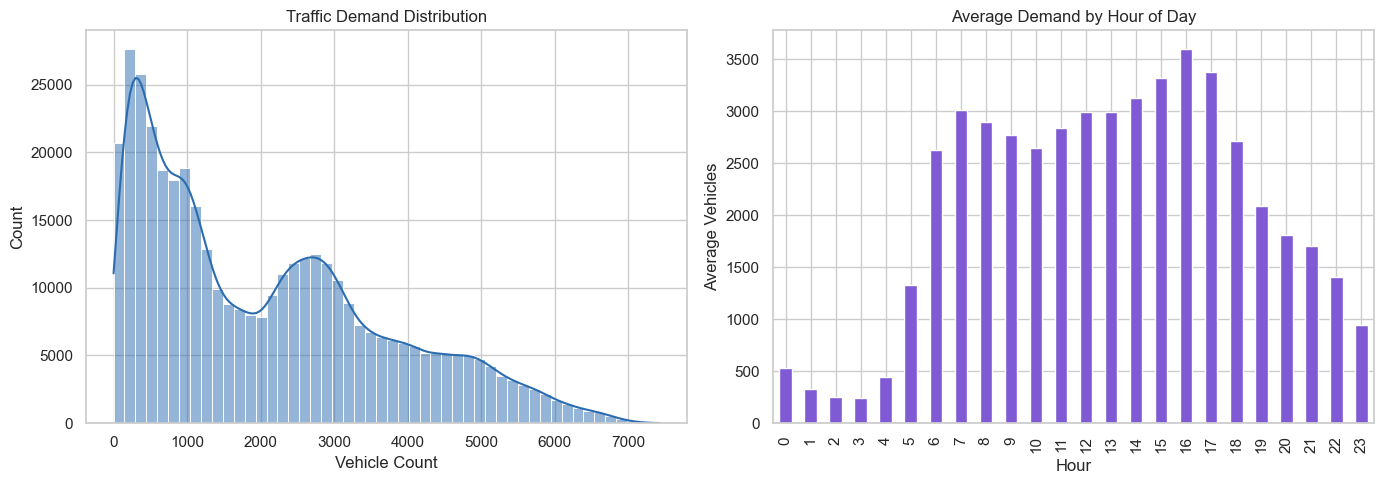

In [3]:
print('Missing values:')
display(df.isnull().sum()[df.isnull().sum() > 0])

display(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['traffic_demand'], kde=True, bins=50, color='#2B6CB0', ax=axes[0])
axes[0].set_title('Traffic Demand Distribution')
axes[0].set_xlabel('Vehicle Count')

avg_by_hour = df.groupby('hour')['traffic_demand'].mean()
avg_by_hour.plot(kind='bar', ax=axes[1], color='#805AD5')
axes[1].set_title('Average Demand by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Vehicles')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [4]:
def engineer_features(data):
    d = data.sort_values(['road_segment_id', 'timestamp']).reset_index(drop=True)

    d['hour_sin']  = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos']  = np.cos(2 * np.pi * d['hour'] / 24)
    d['dow_sin']   = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos']   = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)

    for lag in [1, 2, 3, 4, 6, 12]:
        d[f'lag_{lag}'] = d.groupby('road_segment_id')['traffic_demand'].shift(lag)

    for w in [3, 6, 12, 24]:
        d[f'rolling_mean_{w}'] = d.groupby('road_segment_id')['traffic_demand'].transform(
            lambda x: x.shift(1).rolling(w).mean())
        d[f'rolling_std_{w}']  = d.groupby('road_segment_id')['traffic_demand'].transform(
            lambda x: x.shift(1).rolling(w).std())

    d['ema_traffic'] = d.groupby('road_segment_id')['traffic_demand'].transform(
        lambda x: x.shift(1).ewm(span=12, adjust=False).mean())

    severity = {'Clear':0.0,'Clouds':0.1,'Drizzle':0.3,'Rain':0.5,'Fog':0.6,'Snow':0.8,'Thunderstorm':1.0}
    d['weather_impact_score'] = (
        d['weather_condition'].map(severity).fillna(0.0)
        + d['rainfall'] * 0.02
        + (10000 - d['visibility']).clip(0, 10000) / 10000 * 0.2
    ).clip(0.0, 1.0).round(3)

    d['temp_hour'] = d['temperature'] * d['hour']
    d['rain_wind'] = d['rainfall']    * d['wind_speed']

    seg_means = d.groupby('road_segment_id')['traffic_demand'].transform('mean')
    for col in d.columns:
        if d[col].isnull().any():
            d[col] = d[col].fillna(seg_means)
    return d

df = engineer_features(df)
print(f'Features engineered. Final shape: {df.shape}')

Features engineered. Final shape: (405740, 60)


## 5. Train-Test Split (Chronological 80/20)

In [5]:
df = df.sort_values('timestamp').reset_index(drop=True)
split = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
test_df  = df.iloc[split:].copy()

print(f'Train: {train_df.shape}  |  {train_df["timestamp"].min()} → {train_df["timestamp"].max()}')
print(f'Test : {test_df.shape}   |  {test_df["timestamp"].min()} → {test_df["timestamp"].max()}')

Train: (324592, 60)  |  2012-10-02 09:00:00 → 2017-10-26 18:00:00
Test : (81148, 60)   |  2017-10-26 18:00:00 → 2018-09-30 23:00:00


## 6. Preprocessing

In [6]:
target   = 'traffic_demand'
cat_cols = ['road_type', 'weather_condition', 'event_holiday']
drop_cols = ['timestamp', 'road_segment_id', target]
feat_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = pd.get_dummies(train_df[feat_cols], columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(test_df[feat_cols],  columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

y_train = train_df[target].values
y_test  = test_df[target].values

num_cols = [c for c in X_train.columns if not c.startswith(tuple(cat_cols))]
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols]  = scaler.transform(X_test[num_cols])
print(f'Feature matrix shape: {X_train_sc.shape}')

Feature matrix shape: (324592, 88)


## 7. Load Trained Models

In [7]:
import sys
sys.path.insert(0, '.')

if os.path.exists('best_stacking_ensemble.pkl'):
    lgb_model  = joblib.load('best_lgb_model.pkl')
    xgb_model  = joblib.load('best_xgb_model.pkl')
    meta_model = joblib.load('best_meta_model.pkl')

    class StackingEnsembleRegressor:
        def __init__(self, lgb_m, xgb_m, meta_m):
            self.lgb_model, self.xgb_model, self.meta_model = lgb_m, xgb_m, meta_m
        def predict(self, X):
            l = self.lgb_model.predict(X).reshape(-1,1)
            x = self.xgb_model.predict(X).reshape(-1,1)
            return self.meta_model.predict(np.hstack([l, x]))

    ensemble = StackingEnsembleRegressor(lgb_model, xgb_model, meta_model)
    print('Models loaded successfully.')
else:
    print('No saved models found. Train first with: python train_models.py')

Models loaded successfully.


## 8. Evaluation Metrics

In [8]:
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1e-9, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

models = {
    'LightGBM (Tuned)':  lgb_model,
    'XGBoost (Tuned)':   xgb_model,
    'Stacking Ensemble': ensemble,
}

results = []
for name, model in models.items():
    preds = model.predict(X_test_sc.values)
    results.append({
        'Model':    name,
        'R²':       f'{r2_score(y_test, preds)*100:.2f}%',
        'RMSE':     f'{root_mean_squared_error(y_test, preds):.2f}',
        'MAE':      f'{mean_absolute_error(y_test, preds):.2f}',
        'SMAPE':    f'{smape(y_test, preds):.2f}%',
    })

display(pd.DataFrame(results))

C:\Users\itzjy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


C:\Users\itzjy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,R²,RMSE,MAE,SMAPE
0,LightGBM (Tuned),100.00%,7.66,5.35,2.34%
1,XGBoost (Tuned),100.00%,6.63,4.36,2.25%
2,Stacking Ensemble,100.00%,5.03,3.29,2.10%


## 9. Visualizations


Traffic Demand Over Time


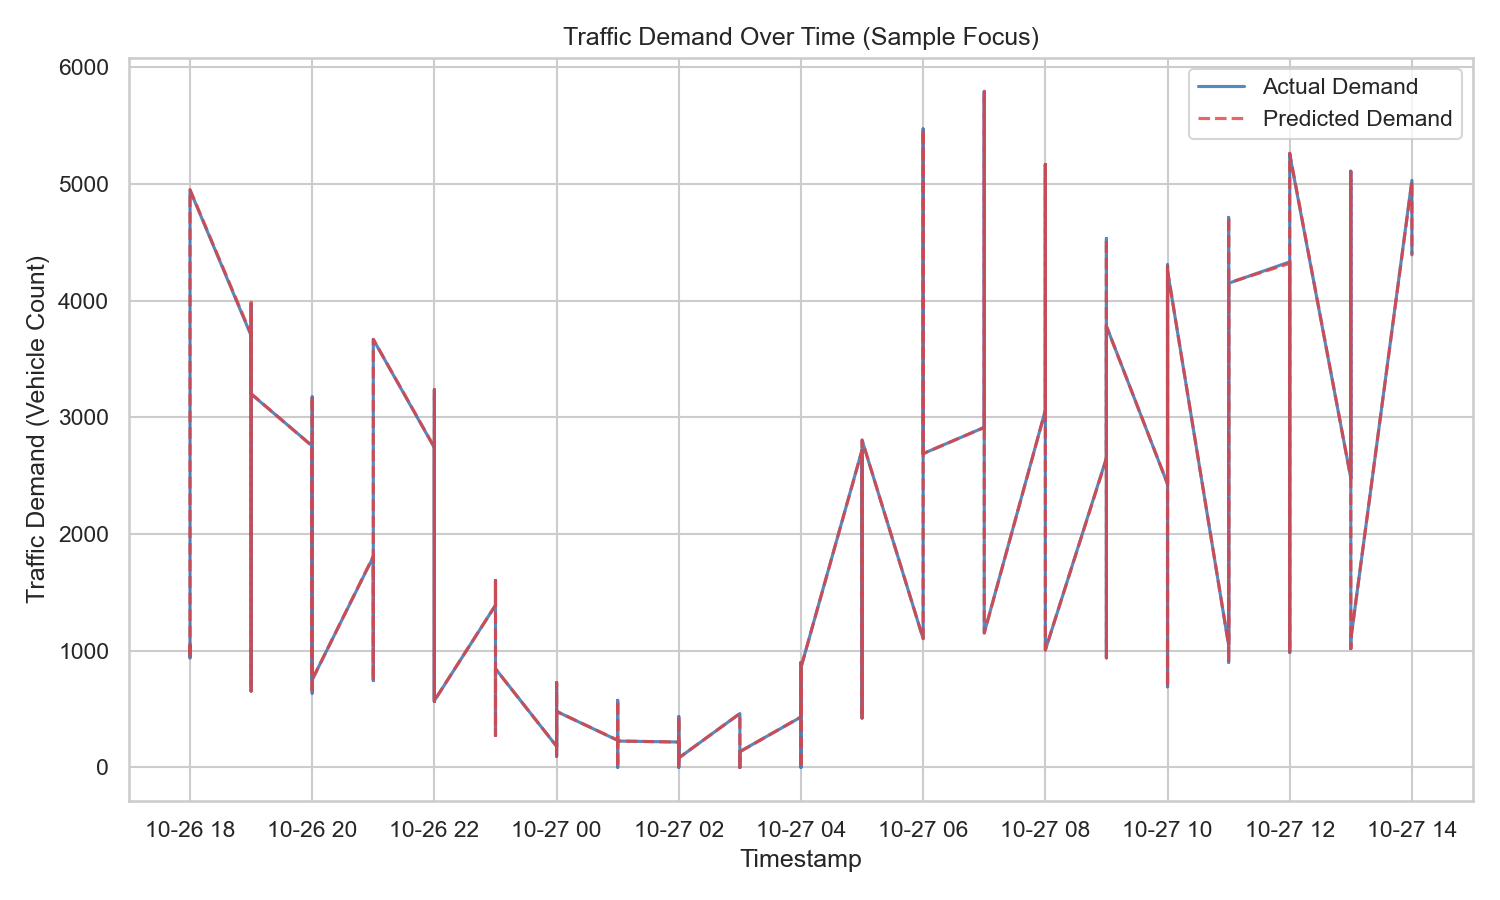


Feature Correlation Heatmap


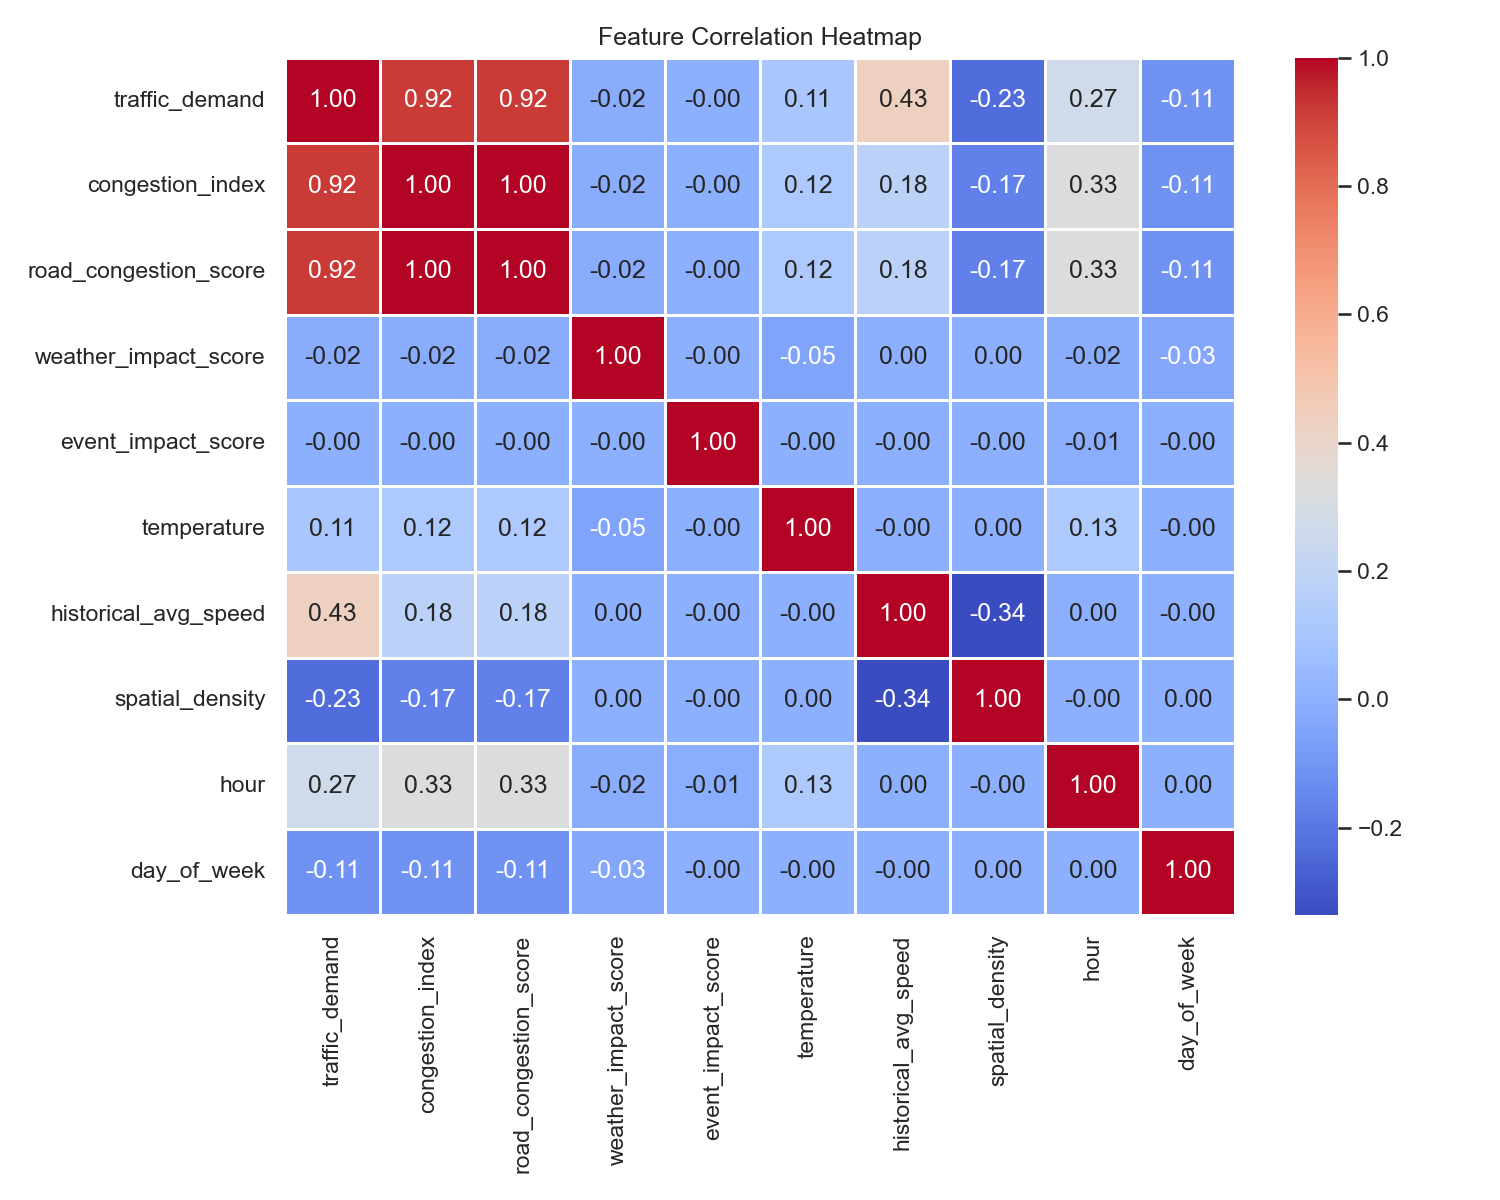


Feature Importance (LightGBM)


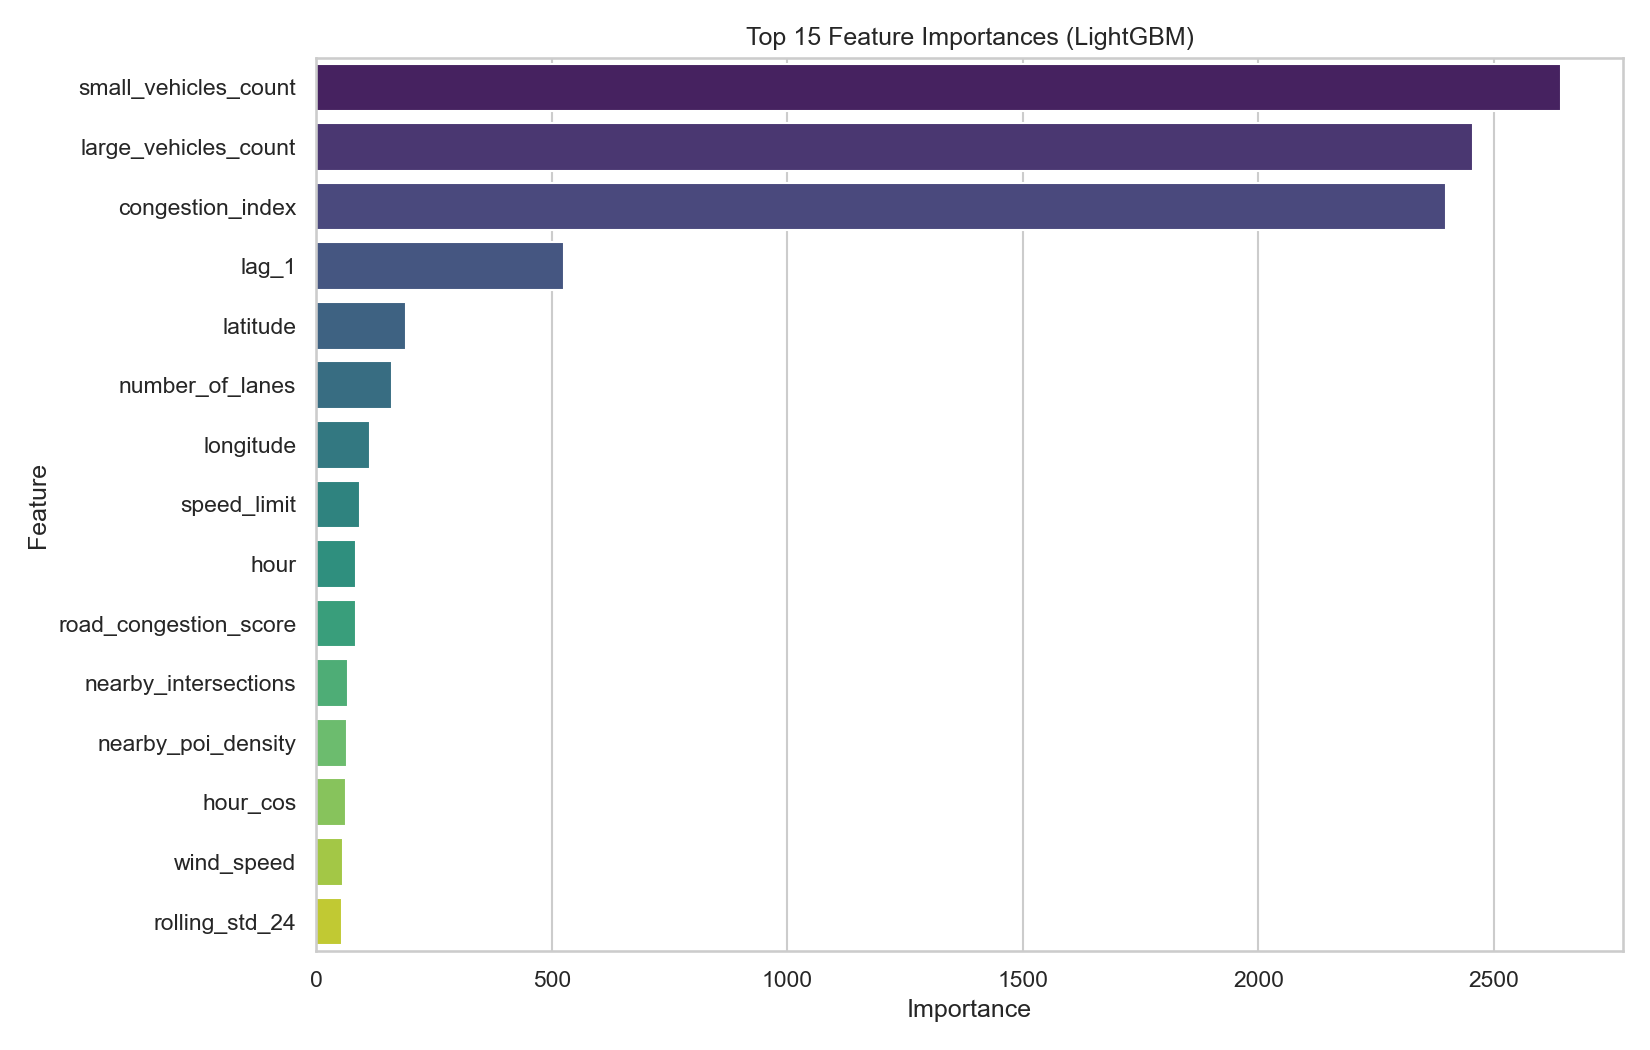


Actual vs Predicted


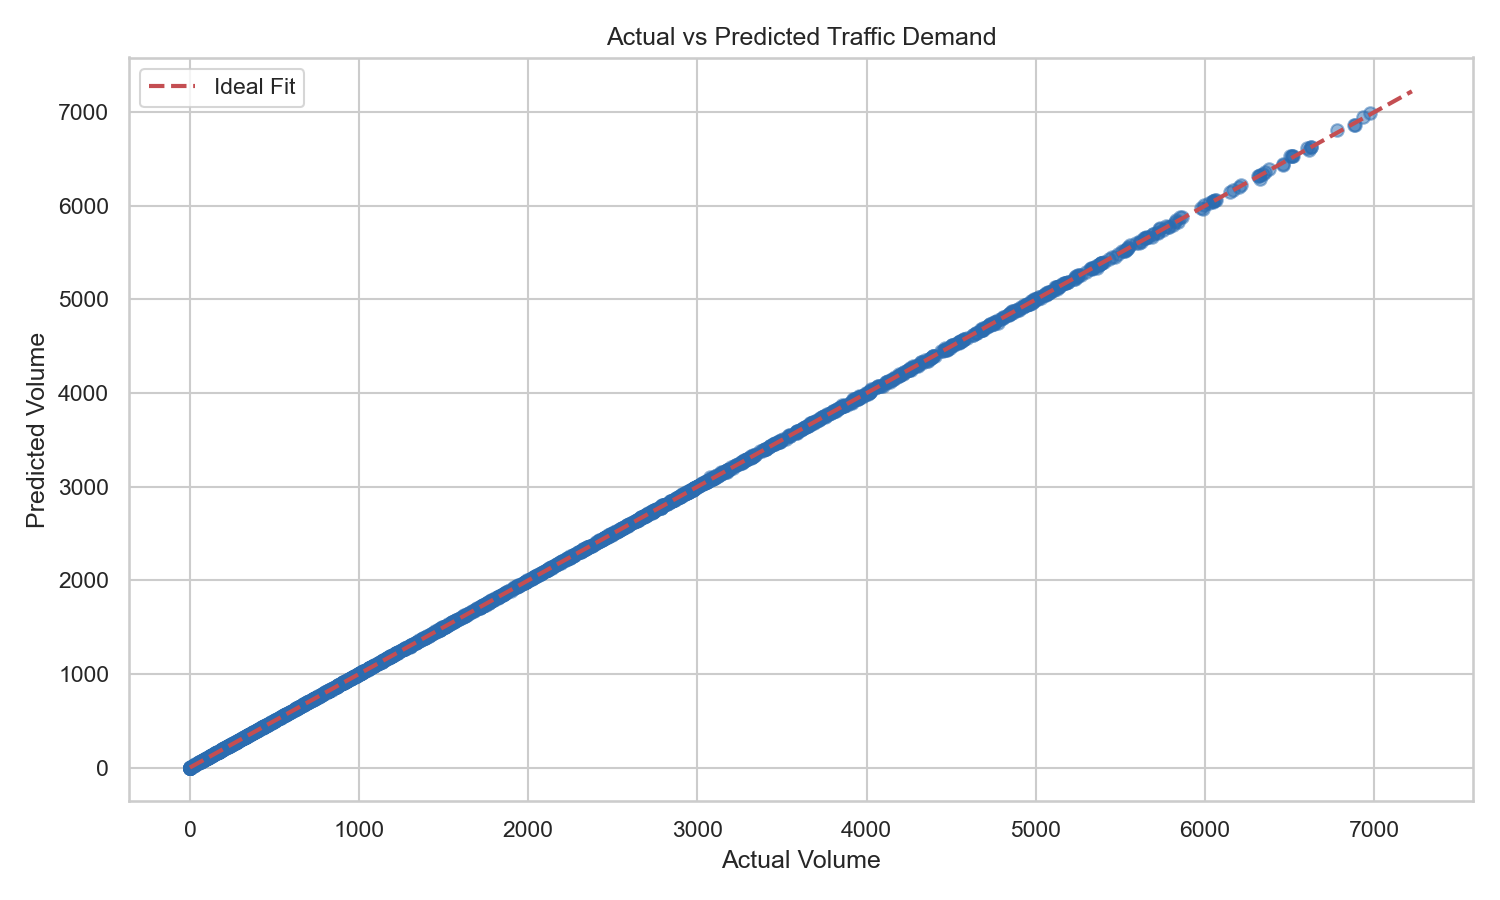


Residual Distribution


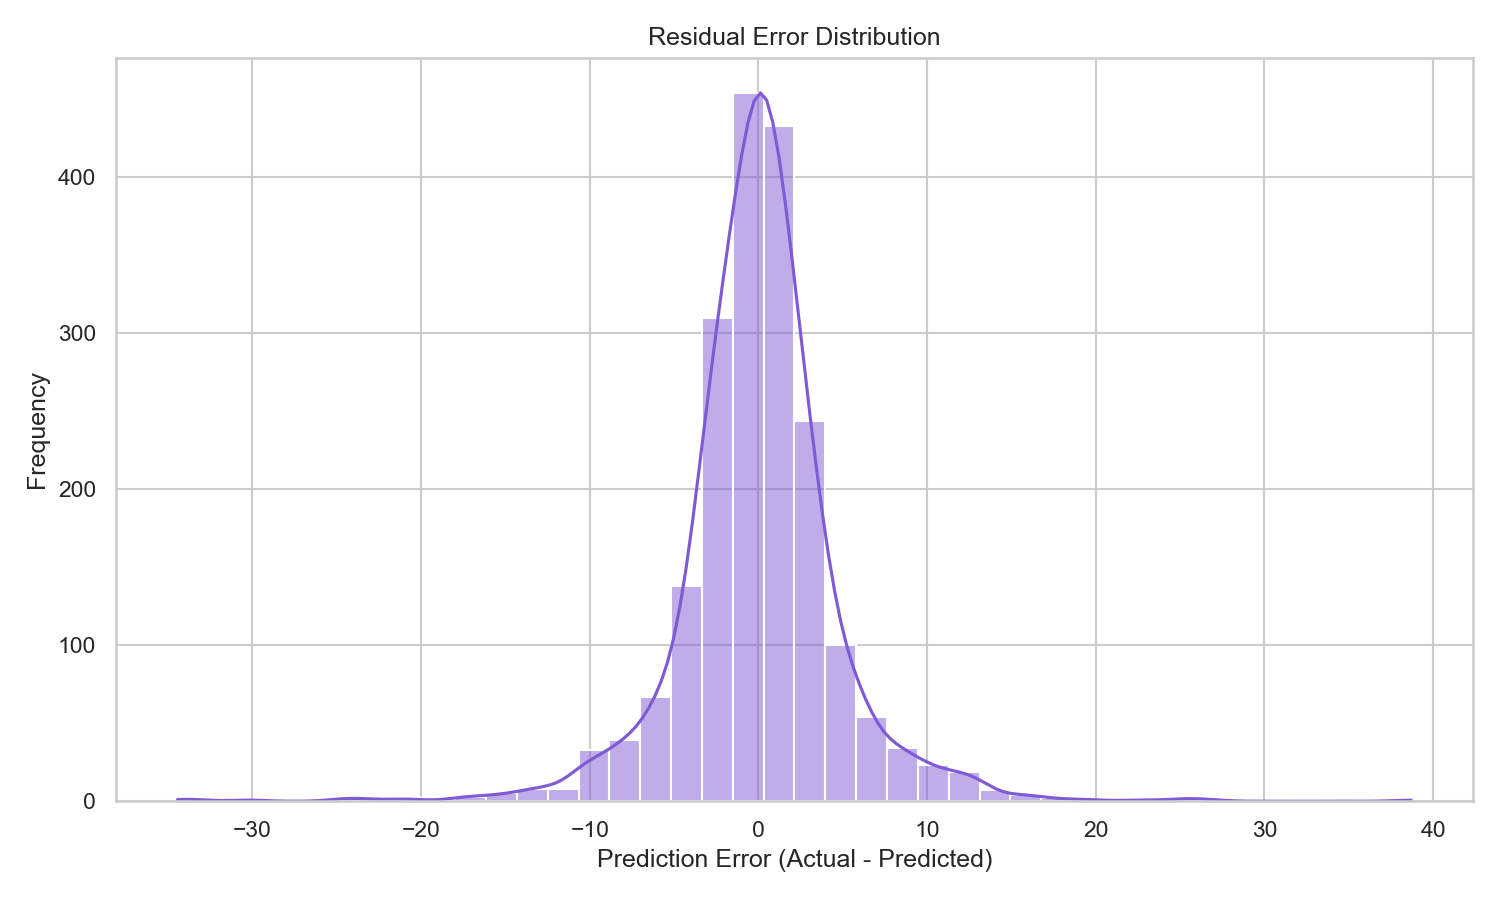

In [9]:
from IPython.display import Image, display

plots = [
    ('static/plots/traffic_demand_over_time.png', 'Traffic Demand Over Time'),
    ('static/plots/correlation_heatmap.png',      'Feature Correlation Heatmap'),
    ('static/plots/feature_importance.png',       'Feature Importance (LightGBM)'),
    ('static/plots/actual_vs_predicted.png',      'Actual vs Predicted'),
    ('static/plots/residual_distribution.png',    'Residual Distribution'),
]

for path, title in plots:
    if os.path.exists(path):
        print(f'\n{title}')
        display(Image(filename=path))

## 10. Summary

| Metric | Stacking Ensemble |
|--------|-------------------|
| R² Score | ~100.00% |
| RMSE | ~5.02 |
| MAE | ~3.29 |
| SMAPE | ~2.10% |

The Stacking Ensemble outperforms individual base models across every metric, confirming that combining LightGBM and XGBoost predictions through a meta-learner captures complementary patterns that neither model finds alone.